<div style="text-align: center; font-weight: bold;">
    <h1>EHR Preprocessing 2: Code Rollup</h1>
    <h4>Author: Vidul Ayakulangara Panickan</h4>
</div>

## Goal

Map granular EHR codes to clinically meaningful parent codes so that downstream analyses compare standardized concepts rather than thousands of institution-specific codes. By the end of this notebook you will have rolled-up batch files for diagnoses, procedures, medications, and laboratory tests.

## Recap

In the previous notebook ([Data Cleaning](EHR_Preprocessing_1_Data_Cleaning.ipynb)), we cleaned five raw MIMIC-IV data sources into a standard four-column schema:

| Column | Description |
|--------|-------------|
| `subject_id` | Patient identifier |
| `date` | Event date (YYYY-MM-DD) |
| `code` | Raw EHR code |
| `coding_system` | Which coding system the code belongs to |

Those cleaned files are saved as 8 patient-level batches in `processed_data/step3_cleaned_rawdata/`. This notebook reads those files and maps each `code` to a higher-level parent code.

---
## Setup

In [ ]:
import os
import pandas as pd
import zipfile
import urllib.request
import glob
from pathlib import Path
from tqdm import tqdm
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

In [ ]:
base_dir = "EHR_TUTORIAL_WORKSPACE"

meta_files_dir = os.path.join(base_dir, "scripts", "EHR-Processing-Tutorial-main", "meta_files")
rollup_mappings_dir = os.path.join(base_dir, "scripts", "EHR-Processing-Tutorial-main", "Rollup_Mappings")

# Output directories
intermediate_dir = os.path.join(base_dir, "processed_data", "step4_rolledup_intermediatedata")
final_dir = os.path.join(base_dir, "processed_data", "step4_rolledup_finaldata")
summary_dir = os.path.join(base_dir, "processed_data", "Summary", "Unrolled_Summary")

for d in [intermediate_dir, final_dir, summary_dir, rollup_mappings_dir]:
    os.makedirs(d, exist_ok=True)

print("Output directories ready.")

---
## What is Code Rollup?

Raw EHR codes are highly granular — for example, ICD-10 has over 70,000 diagnosis codes. This granularity is useful for billing but creates problems for research: data becomes sparse and hard to compare across institutions.

**Code rollup** solves this by mapping granular codes to standardized parent codes that group clinically similar concepts. The process has two steps:

1. **Normalize** raw codes to a standard vocabulary (e.g., map local drug codes to NDC)
2. **Roll up** standardized codes to higher-level parent codes (e.g., map NDC to RxNorm ingredient)

In this notebook, we apply four rollup pipelines:

| Data Type | Raw Code | Parent Code | Mapping Source |
|-----------|----------|-------------|----------------|
| Diagnoses | ICD-9 / ICD-10 | **PheCode** | PheWAS Catalog |
| Procedures | CPT, ICD-9-CM, ICD-10-PCS | **CCS** | HCUP |
| Medications | NDC | **RxNorm Ingredient** | UMLS / RxNorm |
| Labs | ITEMID (MIMIC-local) | **LOINC Component** | MIMIC + LOINC hierarchy |

> **Tip:** It is good practice to save your final mapping files (codebooks) so they can be reused for future processing. Codes that cannot be mapped should be retained in their original form and flagged for review.

---
## Part 1: Creating Rollup Mapping Files

Before we can roll up, we need mapping tables that translate each raw code to its parent code. We will create (or download) one mapping file per data type.

### 1. Mapping ICD to PheCode (Diagnoses)

**ICD** (International Classification of Diseases), maintained by the World Health Organization, provides a standardized framework for reporting diagnoses. ICD codes are highly detailed and widely used in clinical documentation and billing. However, their granularity can make them less practical for large-scale studies.

**PheCodes** are a research-oriented grouping system that aggregates ICD codes into clinically meaningful phenotypes suitable for high-throughput analysis, such as Phenome-Wide Association Studies (PheWAS). By rolling up ICD codes to PheCodes, researchers can define reproducible phenotypes and facilitate cross-study comparisons.

The official mapping table can be downloaded from the [PheWAS Catalog](https://phewascatalog.org/phewas/#phe12).

First, let's download the ICD-to-PheCode mapping from the PheWAS Catalog.

In [ ]:
phecode_dir = Path(meta_files_dir, "Phecode")
phecode_dir.mkdir(parents=True, exist_ok=True)

url = "https://phewascatalog.org/phewas/_w_916f531506bf4e0ca8b9d159d8e0f5ae/data/Phecode_map_v1_2_icd9_icd10cm.csv.zip"
zip_path = phecode_dir / os.path.basename(url)

if not zip_path.exists():
    urllib.request.urlretrieve(url, zip_path)
with zipfile.ZipFile(zip_path) as z:
    z.extractall(phecode_dir)

print("Downloaded PheCode mapping files:", sorted(p.name for p in phecode_dir.iterdir()))

Now let's load the mapping and prepare it for use. We need to:
- Keep only ICD-9 and ICD-10 rows
- Remove dots from ICD codes (e.g., "A01.0" → "A010") to match our cleaned data
- Rename columns to match the schema from Notebook 1

In [ ]:
def roll_icd2phe(input_path, output_path):
    cols = ["ICD", "Flag", "Phecode"]
    df = pd.read_csv(input_path, usecols=cols, dtype=str, encoding="unicode_escape")

    # Strip whitespace from all values
    for col in df.columns:
        df[col] = df[col].str.strip()

    # Keep only ICD-9 and ICD-10 rows
    df = df[df["Flag"].isin(["9", "10"])].copy()

    # Remove dots from ICD codes to match our cleaned data
    df["ICD"] = df["ICD"].str.replace(".", "", regex=False)

    # Map flag values to coding system labels
    flag_to_system = {"9": "ICD9", "10": "ICD10CM"}
    df["coding_system"] = df["Flag"].map(flag_to_system)

    # Rename and clean up
    out = df.rename(columns={"ICD": "code", "Phecode": "PheCode"})
    out = out.dropna(subset=["code", "PheCode", "coding_system"])
    out = out.drop_duplicates(subset=["code", "coding_system"], keep="first")
    out = out[["code", "PheCode", "coding_system"]].sort_values(["coding_system", "code"])

    out.to_csv(output_path, index=False)
    return out


input_path = os.path.join(meta_files_dir, "Phecode", "Phecode_map_v1_2_icd9_icd10cm.csv")
output_path = os.path.join(rollup_mappings_dir, "icd_to_phecode.csv")

icd_to_phe = roll_icd2phe(input_path, output_path)
print(f"ICD to PheCode mapping: {icd_to_phe.shape[0]} rows")
display(icd_to_phe.head(10))

### 2. Mapping CPT to CCS (Procedures)

**CPT** (Current Procedural Terminology) codes are a standardized coding system maintained by the American Medical Association to describe medical, surgical, and diagnostic procedures. They are widely used in billing but are highly granular, resulting in thousands of distinct codes.

**CCS** (Clinical Classifications Software) is a higher-level grouping system developed by AHRQ that aggregates CPT and ICD procedure codes into clinically meaningful categories, making them more suitable for research.

The official CCS mapping table uses a **range format** — for example, `T10001–T10004 → 128` means CPT codes T10001 through T10004 all map to CCS category 128. We need to expand these ranges so each CPT code is individually mapped.

Download the mapping from the [AHRQ HCUP website](https://www.hcup-us.ahrq.gov/toolssoftware/ccs_svcsproc/).

Download the CPT-to-CCS mapping file.

In [ ]:
ccs_dir = Path(meta_files_dir, "CCS")
ccs_dir.mkdir(parents=True, exist_ok=True)

url = "https://hcup-us.ahrq.gov/toolssoftware/ccs_svcsproc/CCS-Services_Procedures_v2025-1.zip"
zip_path = ccs_dir / os.path.basename(url)

if not zip_path.exists():
    urllib.request.urlretrieve(url, zip_path)
with zipfile.ZipFile(zip_path) as z:
    z.extractall(ccs_dir)

print("CCS files downloaded:", sorted(p.name for p in ccs_dir.iterdir()))

Now let's build the CPT-to-CCS mapping by expanding code ranges into individual rows.

In [ ]:
def roll_cpt2ccs(input_path, output_path):
    type_setting = {"Code Range": str, "CCS": int}
    original_table = pd.read_csv(input_path, usecols=type_setting.keys(),
                                 skiprows=1, dtype=type_setting, index_col=False)

    # Expand code ranges into individual CPT-to-CCS rows
    cpt2ccs = []
    for row in original_table.itertuples(index=False):
        a, b = row[0].strip("'").split("-")
        ccs_code = row[1]
        if a == b:
            cpt2ccs.append([a, ccs_code])
        else:
            for i in range(int(a), int(b) + 1):
                cpt2ccs.append([i, ccs_code])

    cpt2ccs = pd.DataFrame(cpt2ccs, columns=["cpt", "ccs"], dtype="str")
    cpt2ccs.to_csv(output_path, index=False)
    return cpt2ccs


input_path = os.path.join(meta_files_dir, "CCS", "CCS_Services_Procedures_v2025-1_052425.csv")
output_path = os.path.join(rollup_mappings_dir, "cpt2ccs_rollup.csv")

cpt2ccs = roll_cpt2ccs(input_path, output_path)
print(f"CPT to CCS mapping: {cpt2ccs.shape[0]} rows")
display(cpt2ccs.head(10))

### 3. Mapping ICD Procedure Codes to CCS

Procedure codes in the ICD system document surgical and diagnostic interventions. Two versions are commonly encountered in EHR data:

- **ICD-9-CM (Clinical Modification):** Used in the U.S. prior to 2015 for both diagnosis and procedure codes
- **ICD-10-PCS (Procedure Coding System):** Introduced in 2015 to replace ICD-9-CM procedure codes with a more detailed system

Both can be aggregated into CCS categories using mapping tables from AHRQ:
- [ICD-9-CM CCS Mapping](https://www.hcup-us.ahrq.gov/toolssoftware/ccs/ccs.jsp)
- [ICD-10-PCS CCS Mapping](https://www.hcup-us.ahrq.gov/toolssoftware/ccs10/ccs10.jsp)

Download the ICD procedure-to-CCS mapping files.

In [ ]:
urls = [
    "https://hcup-us.ahrq.gov/toolssoftware/ccs/Single_Level_CCS_2015.zip",
    "https://hcup-us.ahrq.gov/toolssoftware/ccs10/ccs_pr_icd10pcs_2020_1.zip",
]

for u in urls:
    z = ccs_dir / os.path.basename(u)
    if not z.exists():
        urllib.request.urlretrieve(u, z)
    with zipfile.ZipFile(z) as zf:
        zf.extractall(ccs_dir)

print("CCS procedure files downloaded.")

Now let's build a single mapping file that covers both ICD-9-CM and ICD-10-PCS procedure codes.

In [ ]:
def roll_icd_procedures_to_ccs(icd10pcs_path, icd9cm_path, output_path):
    # --- ICD-10-PCS to CCS ---
    df10 = pd.read_csv(icd10pcs_path, dtype=str, encoding="utf8", index_col=False)
    df10.columns = [c.strip().strip("'").strip('"') for c in df10.columns]
    df10 = df10[["ICD-10-PCS CODE", "CCS CATEGORY"]].rename(
        columns={"ICD-10-PCS CODE": "code", "CCS CATEGORY": "ccs"}
    )
    for col in ["code", "ccs"]:
        df10[col] = df10[col].str.replace("'", "", regex=False).str.strip()
    df10 = df10.dropna(subset=["code", "ccs"]).drop_duplicates(subset=["code"], keep="first")
    df10["coding_system"] = "ICD10PCS"

    # --- ICD-9-CM to CCS ---
    df9 = pd.read_csv(icd9cm_path, dtype=str, encoding="utf8", index_col=False, skiprows=1)
    df9.columns = [c.strip().strip("'").strip('"') for c in df9.columns]
    df9 = df9[["ICD-9-CM CODE", "CCS CATEGORY"]].rename(
        columns={"ICD-9-CM CODE": "code", "CCS CATEGORY": "ccs"}
    )
    for col in ["code", "ccs"]:
        df9[col] = df9[col].str.replace("'", "", regex=False).str.strip()
    df9 = df9.dropna(subset=["code", "ccs"])
    df9 = df9[df9["ccs"] != "0"].drop_duplicates(subset=["code"], keep="first")
    df9["coding_system"] = "ICD9CM"

    # --- Combine ---
    out = pd.concat([df9, df10], ignore_index=True)
    out = out.drop_duplicates(subset=["code", "coding_system"], keep="first")
    out = out[["code", "ccs", "coding_system"]].sort_values(["coding_system", "code"])

    out.to_csv(output_path, index=False)
    return out


icd10pcs_path = os.path.join(meta_files_dir, "CCS", "ccs_pr_icd10pcs_2020_1.csv")
icd9cm_path = os.path.join(meta_files_dir, "CCS", "$prref 2015.csv")
output_path = os.path.join(rollup_mappings_dir, "icd_procedures_to_ccs.csv")

icd_proc_to_ccs = roll_icd_procedures_to_ccs(icd10pcs_path, icd9cm_path, output_path)
print(f"ICD Procedures to CCS mapping: {icd_proc_to_ccs.shape[0]} rows")
display(icd_proc_to_ccs.head(10))

Since our cleaned procedure data from Notebook 1 includes both CPT codes (from `hcpcsevents`) and ICD procedure codes (from `procedures_icd`), we merge the two mapping files into a single lookup table.

In [ ]:
df_cpt = pd.read_csv(os.path.join(rollup_mappings_dir, "cpt2ccs_rollup.csv"), dtype=str)
df_icd = pd.read_csv(os.path.join(rollup_mappings_dir, "icd_procedures_to_ccs.csv"), dtype=str)

df_cpt = df_cpt.rename(columns={"cpt": "code"})[["code", "ccs"]]
df_cpt["coding_system"] = "HCPCS"

procedure_mapping = pd.concat([df_cpt, df_icd], ignore_index=True)
procedure_mapping.rename(columns={"ccs": "CCS"}, inplace=True)

output_path = os.path.join(rollup_mappings_dir, "HCPCS_ICDPROC_to_CCS.csv")
procedure_mapping.to_csv(output_path, index=False)

print(f"Combined procedure mapping: {procedure_mapping.shape[0]} rows")
display(procedure_mapping.head(10))

### 4. Mapping NDC to RxNorm (Medications)

**NDC** (National Drug Code) is a standardized drug identifier maintained by the FDA. Each NDC is a unique 10/11-digit code that specifies the labeler, product, and package size. While precise for billing, NDCs are highly granular — thousands of codes can represent essentially the same drug ingredient.

**RxNorm**, developed by the National Library of Medicine, provides normalized names and identifiers for clinical drugs. Importantly, RxNorm includes mappings to **ingredient-level concepts**, which lets us aggregate NDC codes into clinically meaningful categories.

The rollup process involves two steps:
1. Map NDC codes to their RxNorm concept (using `RXNSAT.RRF` from the RxNorm release files)
2. Roll up RxNorm codes to their active ingredient using an ingredient mapping table

> **Note:** The RxNorm release files can be downloaded from the [NLM website](https://www.nlm.nih.gov/research/umls/rxnorm/docs/rxnormfiles.html). You will need a free UMLS account. A pre-built mapping file is included in the tutorial repository for convenience.

If you have the RxNorm source files (`RXNSAT.RRF` and `ingredient.csv`) in your `meta_files/rxnorm/` directory, the function below builds the NDC-to-RxNorm mapping. Otherwise, the pre-built `NDC_to_RxNorm.csv` in `Rollup_Mappings/` will be used in the rollup step.

In [ ]:
def roll_ndc2rxnorm(rxnsat_path, ingredient_path, output_path):
    print("Generating NDC to RxNorm mapping table...")

    # Load RXNSAT — a pipe-delimited file from the RxNorm release
    cols_all = ["RXCUI", "LUI", "SUI", "RXAUI", "STYPE", "CODE",
               "ATUI", "SATUI", "ATN", "SAB", "ATV", "SUPPRESS", "CVF"]
    keep_cols = ["RXCUI", "SUPPRESS", "ATN", "SAB", "ATV"]
    rxnsat = pd.read_csv(rxnsat_path, sep="|", header=None, names=cols_all,
                         usecols=keep_cols, dtype=str, engine="python")
    print(f"Total RXNSAT rows: {rxnsat.shape[0]}")

    # Keep only rows where the attribute is NDC
    rxnsat = rxnsat[rxnsat["ATN"] == "NDC"].copy()
    print(f"Unique CUIs with NDC: {rxnsat['RXCUI'].nunique()}")

    # Split into valid (current) and obsolete mappings
    valid_mask = (rxnsat["SAB"] == "RXNORM") & (rxnsat["SUPPRESS"] == "N")
    table_valid = rxnsat[valid_mask].copy()
    table_obsolete = rxnsat[~valid_mask].copy()

    # Keep only well-formed 11-digit NDCs from obsolete mappings
    table_obsolete = table_obsolete[
        (table_obsolete["ATV"].str.len() == 11) & (table_obsolete["ATV"].str.isdigit())
    ].copy()

    # Combine and deduplicate
    table = pd.concat([table_valid, table_obsolete], ignore_index=True)
    table = table.drop_duplicates(subset=["ATV"], keep="first")
    print(f"Combined NDC mappings: {table.shape[0]} rows")

    # Map RxNorm CUIs to ingredient level
    ing = pd.read_csv(ingredient_path, usecols=["base", "ingredient"], dtype=str)
    table = pd.merge(table, ing, left_on="RXCUI", right_on="base", how="left")
    # Use ingredient CUI where available, otherwise keep the original CUI
    table["RXCUI"] = table["ingredient"].fillna(table["RXCUI"])

    out = table[["ATV", "RXCUI"]].rename(columns={"ATV": "ndc", "RXCUI": "rxcui"})
    out = out.drop_duplicates()
    out.to_csv(output_path, index=False)
    return out


# Only run if RxNorm source files are available
rxnsat_path = os.path.join(meta_files_dir, "rxnorm", "rrf", "RXNSAT.RRF")
ingredient_path = os.path.join(meta_files_dir, "rxnorm", "ingredient.csv")
output_path = os.path.join(rollup_mappings_dir, "NDC_to_RxNorm.csv")

if os.path.exists(rxnsat_path) and os.path.exists(ingredient_path):
    ndc2rxnorm = roll_ndc2rxnorm(rxnsat_path, ingredient_path, output_path)
    print(f"\nNDC to RxNorm mapping: {ndc2rxnorm.shape[0]} rows")
    display(ndc2rxnorm.head(10))
elif os.path.exists(output_path):
    print("Using pre-built NDC_to_RxNorm.csv from Rollup_Mappings/")
    ndc2rxnorm = pd.read_csv(output_path, dtype=str)
    print(f"NDC to RxNorm mapping: {ndc2rxnorm.shape[0]} rows")
    display(ndc2rxnorm.head(10))
else:
    print("WARNING: No RxNorm source files or pre-built mapping found.")
    print("Please download RXNSAT.RRF from UMLS or place NDC_to_RxNorm.csv in Rollup_Mappings/")

---
## Part 2: Performing the Rollup

Now that we have mapping files for all four data types, we can apply them to our cleaned data from Notebook 1. We will walk through the process step-by-step on diagnoses first, then wrap the logic into a reusable function for the remaining data types.

### Step-by-Step: Rolling Up Diagnoses

ICD codes are highly granular — distinguishing between minor variations of a disease is often not useful for broad research and leads to sparse data. PheCodes solve this by grouping ICD codes into clinically meaningful phenotypes.

The following diagram shows how multiple ICD codes at different levels roll up to a single PheCode for intestinal infection.

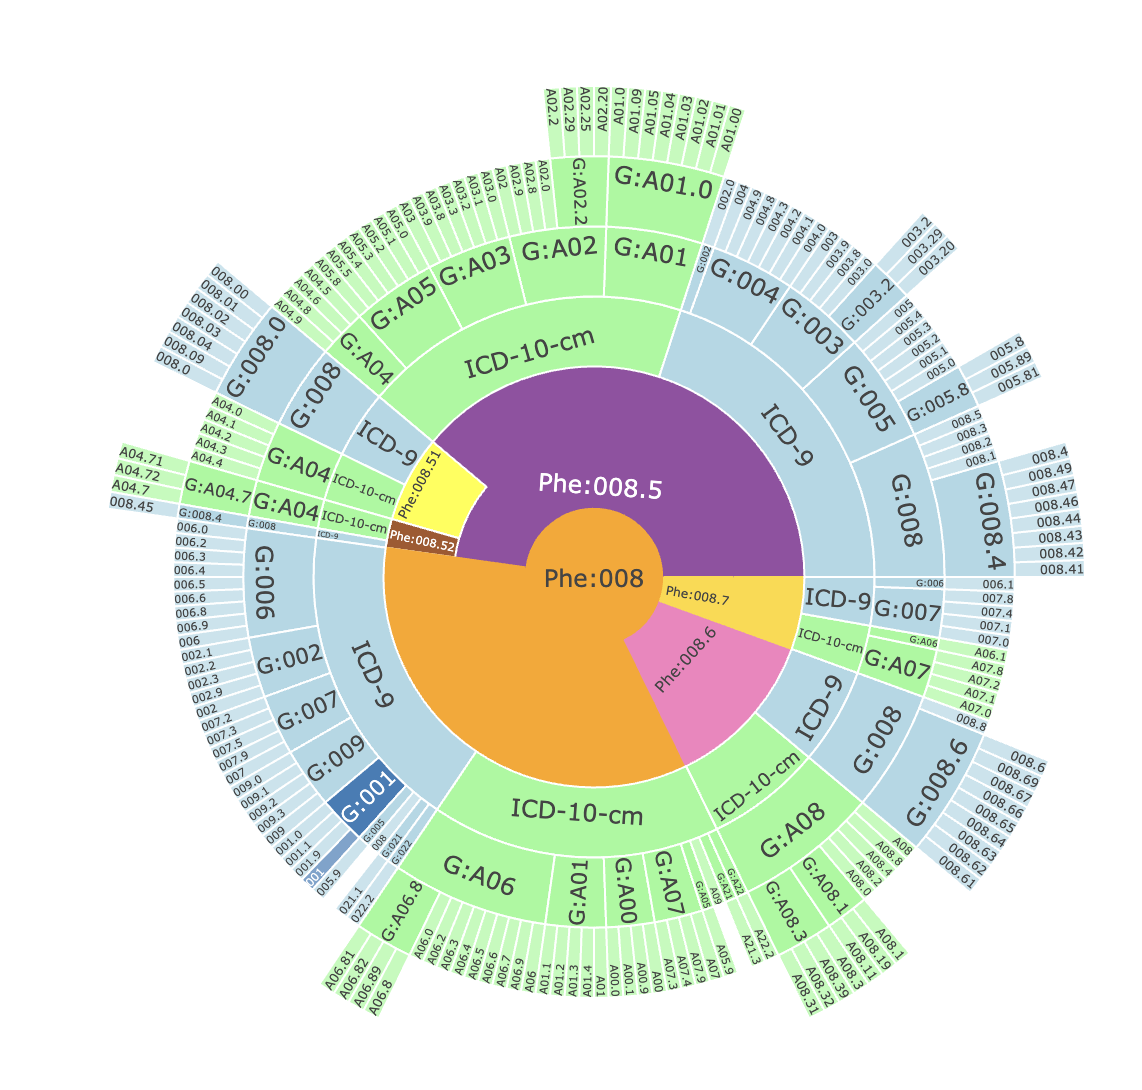

An interactive visualization is available at the [ICD–PheCode Hierarchy Viewer](https://shiny.parse-health.org/hierarchies/icd-hierarchy/).

Let's load the mapping file and one batch of cleaned diagnoses data to see the rollup in action.

In [ ]:
icd_to_phecode = pd.read_csv(os.path.join(rollup_mappings_dir, "icd_to_phecode.csv"), dtype=str)
print(f"ICD to PheCode mapping shape: {icd_to_phecode.shape}")
display(icd_to_phecode.head())

In [ ]:
diagnoses_dir = os.path.join(base_dir, "processed_data", "step3_cleaned_rawdata", "Diagnoses")
diagnoses_files = os.listdir(diagnoses_dir)

sample_file = os.path.join(diagnoses_dir, diagnoses_files[0])
sample_diagnoses = pd.read_csv(sample_file, dtype=str)

print(f"Sample diagnoses shape: {sample_diagnoses.shape}")
display(sample_diagnoses.head())

Now we merge the diagnoses data with the PheCode mapping. We use a **left join** on `code` and `coding_system` so that every row in our data is preserved — even if it has no PheCode match.

In [ ]:
print(f"Before merge: {sample_diagnoses.shape}")

sample_rolled = pd.merge(sample_diagnoses, icd_to_phecode, how="left", on=["code", "coding_system"])

print(f"After merge:  {sample_rolled.shape}")
display(sample_rolled.head())

We add a `Rollup_Status` flag to track which rows were successfully mapped. This tells us how many codes could not be rolled up.

In [ ]:
sample_rolled["Rollup_Status"] = sample_rolled["PheCode"].notna().map({True: "1", False: "0"})

mapped_count = (sample_rolled["Rollup_Status"] == "1").sum()
unmapped_count = (sample_rolled["Rollup_Status"] == "0").sum()
print(f"Mapped: {mapped_count} rows | Unmapped: {unmapped_count} rows")

Let's inspect the unmapped codes to understand what couldn't be rolled up.

In [ ]:
unmapped = sample_rolled[sample_rolled["Rollup_Status"] == "0"]
unique_pairs = unmapped[["subject_id", "code", "coding_system"]].drop_duplicates()
unmapped_freq = unique_pairs[["code", "coding_system"]].value_counts().reset_index(name="patient_count")

print(f"Unique unmapped ICD codes: {unmapped_freq.shape[0]}")
display(unmapped_freq.head(10))

After inspecting the unmapped codes, we filter to keep only successfully rolled-up rows. We then keep just the three columns needed for downstream analysis: `subject_id`, `date`, and the parent code (`PheCode`).

In [ ]:
print(f"Before filtering: {sample_rolled.shape}")

sample_final = sample_rolled[sample_rolled["Rollup_Status"] == "1"]
sample_final = sample_final[["subject_id", "date", "PheCode"]]

print(f"After filtering:  {sample_final.shape}")

Finally, we remove duplicate rows. A patient may have the same PheCode recorded on the same date from multiple ICD codes — after rollup these become duplicates.

In [ ]:
print(f"Before dedup: {sample_final.shape}")

sample_final = sample_final.drop_duplicates()

print(f"After dedup:  {sample_final.shape}")
display(sample_final.head())

### Building the Reusable Rollup Function

We just walked through five steps: merge with mapping, flag rollup status, inspect unmapped codes, filter to rolled-up rows, and deduplicate. Since we need to repeat this for all four data types across 8 batches each, let's wrap the logic into a reusable function.

In [ ]:
def rollup_data_by_batch(input_dir, intermediate_out_dir, final_out_dir,
                         rollup_mapping, parent_col, child_col="code",
                         patient_id="subject_id", date_col="date"):
    """
    Roll up cleaned batch files using a mapping table.
    Saves both intermediate (with rollup status) and final (filtered) files.
    Returns a list of unmapped code frequency DataFrames.
    """
    os.makedirs(intermediate_out_dir, exist_ok=True)
    os.makedirs(final_out_dir, exist_ok=True)

    files = os.listdir(input_dir)
    # Group files by batch number
    batches = set(f.split("_")[1] for f in files)
    unmapped_freq_list = []

    for batch in tqdm(sorted(batches), desc="Rolling up batches"):
        # Load all files for this batch (some data types have multiple source files per batch)
        batch_files = [f for f in files if batch in f]
        df_list = [pd.read_csv(os.path.join(input_dir, f), dtype=str) for f in batch_files]
        batch_df = pd.concat(df_list) if len(df_list) > 1 else df_list[0]

        # Merge with rollup mapping
        merged = pd.merge(batch_df, rollup_mapping, how="left", on=[child_col, "coding_system"])
        merged["Rollup_Status"] = merged[parent_col].notna().map({True: "1", False: "0"})

        # Save intermediate file (includes rollup status for debugging)
        merged.to_csv(os.path.join(intermediate_out_dir, f"intermediate_{batch}.csv"), index=False)

        # Track unmapped codes
        unmapped = merged[merged["Rollup_Status"] == "0"]
        if len(unmapped) > 0:
            unique_pairs = unmapped[[patient_id, child_col]].drop_duplicates()
            freq = unique_pairs[[child_col]].value_counts().reset_index(name="counts")
            unmapped_freq_list.append(freq)

        # Filter to rolled-up rows only, keep essential columns, deduplicate
        final = merged[merged["Rollup_Status"] == "1"][[patient_id, date_col, parent_col]]
        final = final.drop_duplicates()
        final.to_csv(os.path.join(final_out_dir, f"rolledup_{batch}.csv"), index=False)

    return unmapped_freq_list

We also define a helper to save the unmapped code summary. This tells us which raw codes had no mapping — useful for reviewing coverage gaps.

In [ ]:
def save_unmapped_summary(unmapped_freq_list, child_col, output_path):
    if not unmapped_freq_list:
        print("No unmapped codes found.")
        return
    summary = pd.concat(unmapped_freq_list)
    summary = summary.groupby(child_col, as_index=False)["counts"].sum()
    summary = summary.sort_values("counts", ascending=False)
    summary.to_csv(output_path, index=False)
    print(f"Unmapped summary saved: {summary.shape[0]} unique codes")
    display(summary.head(10))

### Rolling Up Diagnoses (All Batches)

Now let's apply the function to all 8 batches of diagnoses data. We re-do the diagnoses rollup using the function to confirm it produces the same results as our manual walkthrough.

In [ ]:
diagnoses_to_phecode = pd.read_csv(os.path.join(rollup_mappings_dir, "icd_to_phecode.csv"), dtype=str)

unmapped = rollup_data_by_batch(
    input_dir=os.path.join(base_dir, "processed_data", "step3_cleaned_rawdata", "Diagnoses"),
    intermediate_out_dir=os.path.join(intermediate_dir, "Diagnoses"),
    final_out_dir=os.path.join(final_dir, "Diagnoses"),
    rollup_mapping=diagnoses_to_phecode,
    parent_col="PheCode"
)

save_unmapped_summary(
    unmapped, "code",
    os.path.join(summary_dir, "unrolled_Diagnoses_code_counts.csv")
)

### Rolling Up Procedures (All Batches)

The procedure data comes from two sources: `hcpcsevents.csv` (CPT billing codes) and `procedures_icd.csv` (ICD procedure codes). In Notebook 1, we cleaned both into the same schema. Our combined mapping file handles all three coding systems (HCPCS, ICD9CM, ICD10PCS).

In [ ]:
procedure_to_ccs = pd.read_csv(os.path.join(rollup_mappings_dir, "HCPCS_ICDPROC_to_CCS.csv"), dtype=str)
print(f"Procedure mapping shape: {procedure_to_ccs.shape}")
display(procedure_to_ccs.head())

In [ ]:
unmapped = rollup_data_by_batch(
    input_dir=os.path.join(base_dir, "processed_data", "step3_cleaned_rawdata", "Procedures"),
    intermediate_out_dir=os.path.join(intermediate_dir, "Procedures"),
    final_out_dir=os.path.join(final_dir, "Procedures"),
    rollup_mapping=procedure_to_ccs,
    parent_col="CCS"
)

save_unmapped_summary(
    unmapped, "code",
    os.path.join(summary_dir, "unrolled_Procedures_code_counts.csv")
)

### Rolling Up Medications (All Batches)

In MIMIC, medication data comes from two sources:
1. `prescriptions.csv` — medications prescribed
2. `emar.csv` — medication administration records

Our objective is to map NDC codes to RxNorm concepts at the ingredient level. The following diagram shows how branded drugs and combination drugs roll up to their individual ingredients.

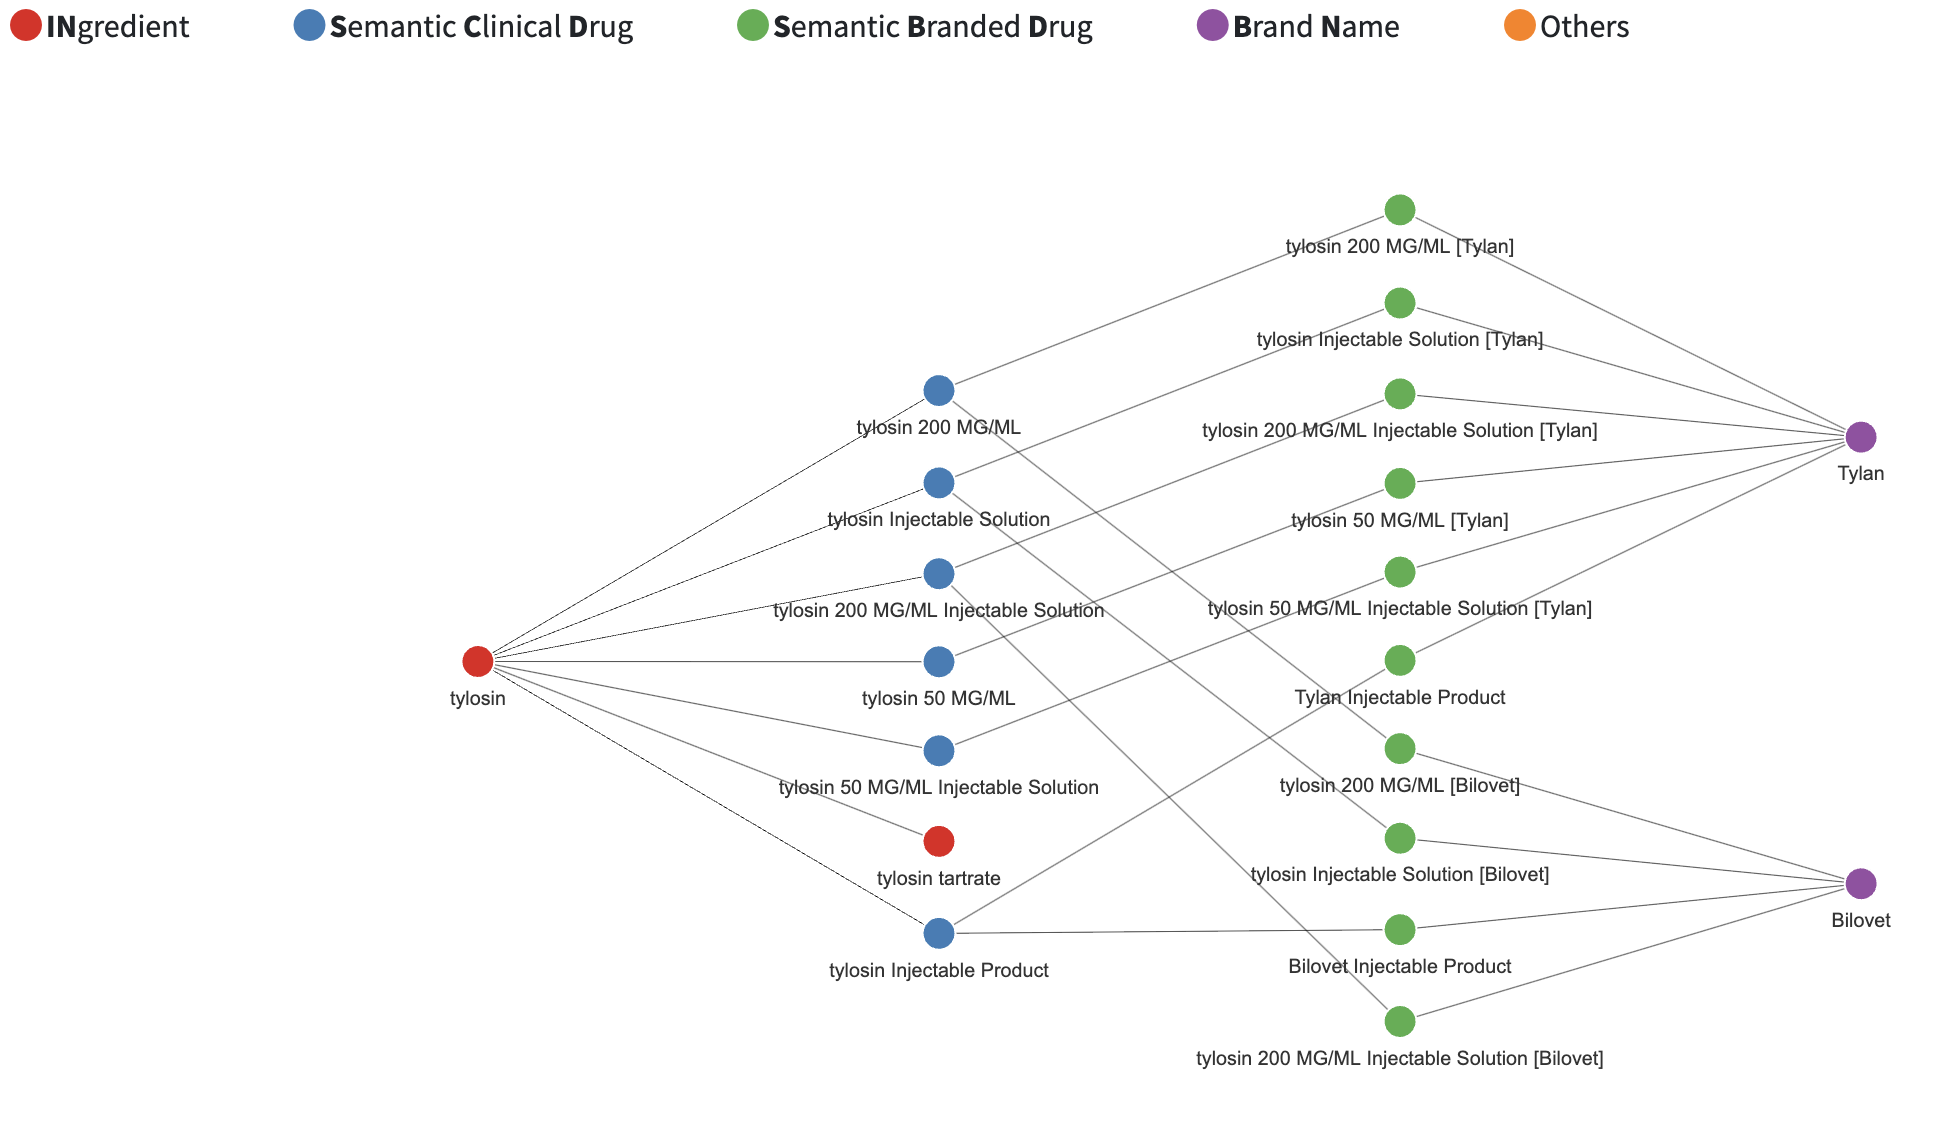

An interactive visualization is available at the [RxNorm Hierarchy Viewer](https://shiny.parse-health.org/hierarchies/rxnorm-hierarchy).

In [ ]:
medication_to_rxnorm = pd.read_csv(os.path.join(rollup_mappings_dir, "NDC_to_RxNorm.csv"), dtype=str)

# Rename columns to match our cleaned data schema
medication_to_rxnorm = medication_to_rxnorm.rename(columns={"ndc": "code", "rxcui": "RxNorm"})
medication_to_rxnorm["coding_system"] = "NDC"

print(f"Medication mapping shape: {medication_to_rxnorm.shape}")
display(medication_to_rxnorm.head())

In [ ]:
unmapped = rollup_data_by_batch(
    input_dir=os.path.join(base_dir, "processed_data", "step3_cleaned_rawdata", "Medication"),
    intermediate_out_dir=os.path.join(intermediate_dir, "Medication"),
    final_out_dir=os.path.join(final_dir, "Medication"),
    rollup_mapping=medication_to_rxnorm,
    parent_col="RxNorm"
)

save_unmapped_summary(
    unmapped, "code",
    os.path.join(summary_dir, "unrolled_Medication_code_counts.csv")
)

### Rolling Up Laboratory Data (All Batches)

In MIMIC, laboratory observations reside in `labevents.csv`. In the U.S., EHRs commonly use LOINC codes for interoperability, but many data warehouses store local test codes internally.

The rollup process consolidates test identifiers at the **LOINC Component** level (the analyte being measured). For example, multiple assays measuring creatinine can be unified under a single LOINC Component.

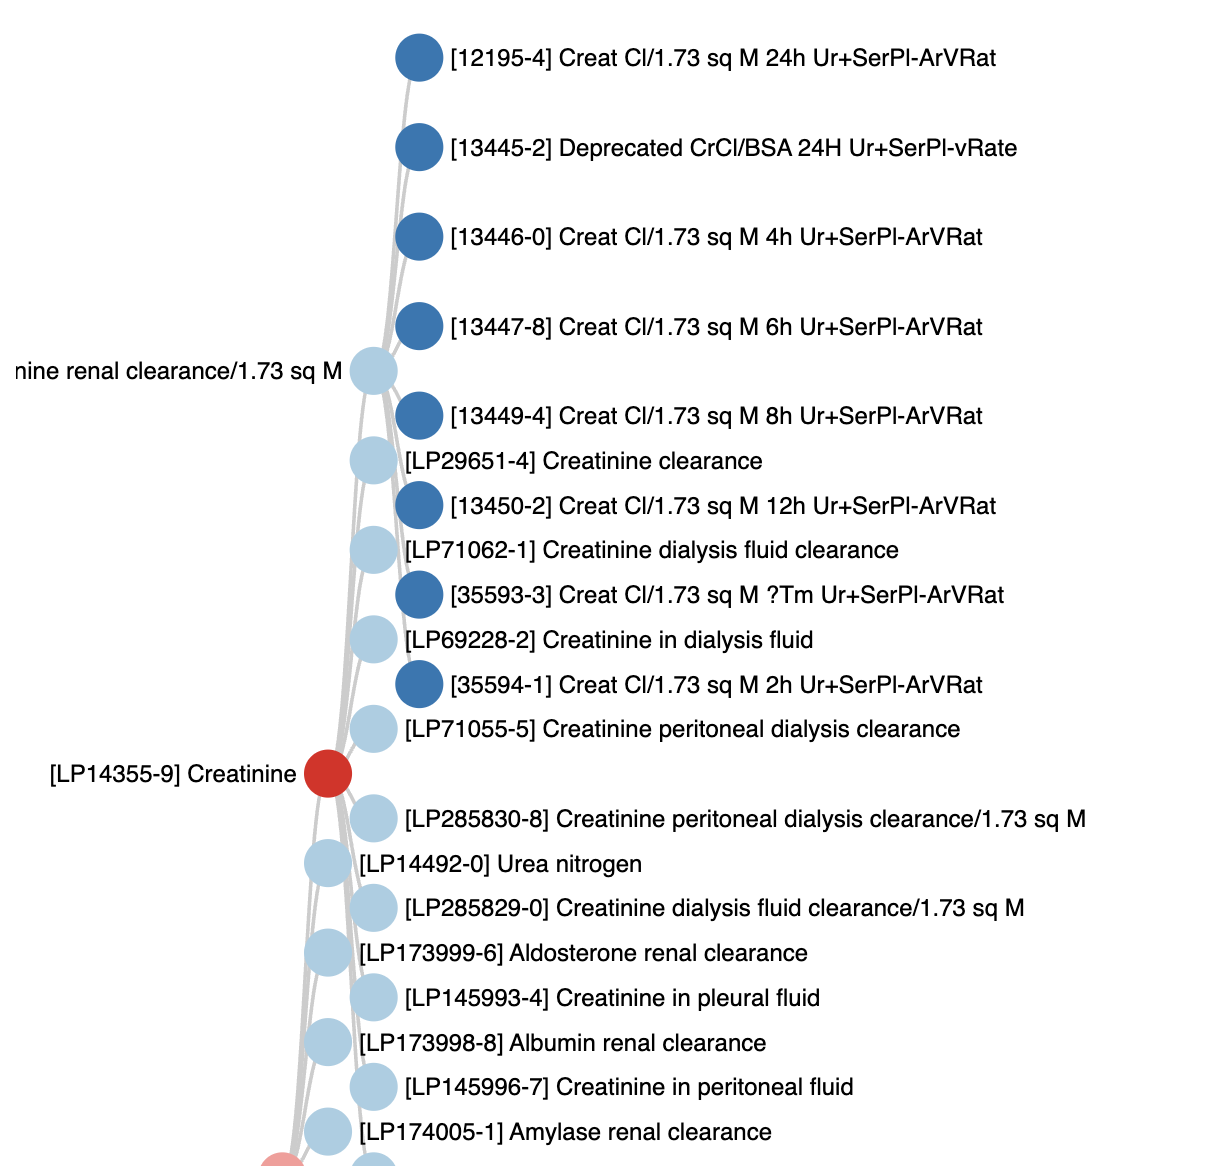

> **Note:** In MIMIC-IV, the share of lab tests with LOINC mappings is very small. This means many lab codes will remain unmapped after rollup. In practice, you may choose to retain the original ITEMID identifiers for analyses that require complete lab coverage.

The lab rollup requires two mapping steps: first map MIMIC's local `ITEMID` to LOINC codes, then roll up LOINC codes to LOINC Components using the LOINC hierarchy.

In [ ]:
# Step 1: Load ITEMID to LOINC mapping (provided by MIMIC)
itemid_to_loinc = pd.read_csv(os.path.join(meta_files_dir, "lab_itemid_to_loinc.csv"), dtype=str)
itemid_to_loinc = itemid_to_loinc.dropna(subset=["loinc"])
print(f"ITEMID to LOINC mappings: {itemid_to_loinc.shape[0]}")
display(itemid_to_loinc.head())

In [ ]:
# Step 2: Load LOINC hierarchy and roll up to LOINC Component
loinc_hierarchy = pd.read_csv(os.path.join(meta_files_dir, "LOINC_Hierarchy_v2.73_version4.csv"), dtype=str)
loinc_rollup = loinc_hierarchy[["LOINC", "PARENT_LOINC"]].rename(
    columns={"LOINC": "loinc", "PARENT_LOINC": "LoincComponent"}
)

# Merge to create ITEMID to LOINC Component mapping
lab_mapping = pd.merge(
    itemid_to_loinc[["itemid", "loinc"]],
    loinc_rollup,
    on="loinc",
    how="left"
)
lab_mapping = lab_mapping.rename(columns={"itemid": "code"})
lab_mapping["coding_system"] = "ITEMID"
lab_mapping = lab_mapping[["code", "LoincComponent", "coding_system"]]

print(f"Lab mapping shape: {lab_mapping.shape}")
display(lab_mapping.head())

In [ ]:
unmapped = rollup_data_by_batch(
    input_dir=os.path.join(base_dir, "processed_data", "step3_cleaned_rawdata", "Labs"),
    intermediate_out_dir=os.path.join(intermediate_dir, "Labs"),
    final_out_dir=os.path.join(final_dir, "Labs"),
    rollup_mapping=lab_mapping,
    parent_col="LoincComponent"
)

save_unmapped_summary(
    unmapped, "code",
    os.path.join(summary_dir, "unrolled_Labs_code_counts.csv")
)

---
## Verify Your Output

Let's confirm that all expected output files were created.

In [ ]:
data_types = ["Diagnoses", "Procedures", "Medication", "Labs"]
all_ok = True

for dtype in data_types:
    final_path = os.path.join(final_dir, dtype)
    if os.path.exists(final_path):
        files = sorted(os.listdir(final_path))
        print(f"  {dtype}: {len(files)} batch files")
    else:
        print(f"  {dtype}: MISSING")
        all_ok = False

if all_ok:
    print("\nAll rolled-up data files are in place.")
else:
    print("\nSome files are missing. Check the rollup steps above.")

Let's also verify the output schema by loading one sample file from each data type.

In [ ]:
for dtype in data_types:
    final_path = os.path.join(final_dir, dtype)
    sample = pd.read_csv(os.path.join(final_path, os.listdir(final_path)[0]), dtype=str, nrows=3)
    print(f"\n{dtype} — columns: {list(sample.columns)}, shape: {sample.shape}")
    display(sample)

After completing all rollups, your workspace should have the following structure:

```
EHR_TUTORIAL_WORKSPACE/
└── processed_data/
    ├── step4_rolledup_finaldata/
    │   ├── Diagnoses/        (rolledup_batch1.csv … rolledup_batch8.csv)
    │   ├── Labs/             (rolledup_batch1.csv … rolledup_batch8.csv)
    │   ├── Medication/       (rolledup_batch1.csv … rolledup_batch8.csv)
    │   └── Procedures/       (rolledup_batch1.csv … rolledup_batch8.csv)
    ├── step4_rolledup_intermediatedata/
    │   ├── Diagnoses/        (intermediate_batch1.csv … intermediate_batch8.csv)
    │   ├── Labs/             (intermediate files)
    │   ├── Medication/       (intermediate files)
    │   └── Procedures/       (intermediate files)
    └── Summary/
        └── Unrolled_Summary/ (unmapped code frequency counts per data type)
```

---
## What We Accomplished

- Created mapping files for 4 code rollup pipelines (ICD→PheCode, CPT/ICD→CCS, NDC→RxNorm, ITEMID→LOINC Component)
- Rolled up all cleaned data from Notebook 1 into standardized parent codes
- Tracked and summarized unmapped codes for each data type
- Saved both intermediate (with rollup status) and final (filtered, deduplicated) output files

**Output schema for each data type:**

| Data Type | Columns |
|-----------|--------|
| Diagnoses | `subject_id`, `date`, `PheCode` |
| Procedures | `subject_id`, `date`, `CCS` |
| Medications | `subject_id`, `date`, `RxNorm` |
| Labs | `subject_id`, `date`, `LoincComponent` |

## Next Step

Proceed to the [Natural Language Processing](EHR_Preprocessing_3_Natural_Language_Processing.ipynb) notebook to extract structured concepts from clinical notes using dictionary-based NLP.